# Changing the SEACells package to SEACells updated to accomodate the SNN Matrix

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad


In [2]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")


In [3]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)
from sklearn.decomposition import PCA

n_components = 50
pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)



Shape of combined_cell_types (25932,)
st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)
(25932, 512)
Reduced shape: (25932, 50)


In [4]:
# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
print("Shape after flattening: ", covet_sqrt_combined.shape)
covet_pca = pca.fit_transform(covet_sqrt_combined)
print("Reduced shape:", covet_pca.shape)

Shape after flattening:  (25932, 4096)
Reduced shape: (25932, 50)


In [5]:
combined_matrix=np.concatenate([covet_pca, envi_pca], axis=1)
print(combined_matrix.shape)

(25932, 100)


### Creating Anndata for the combined matrix

In [6]:
adata=ad.AnnData(X=combined_matrix)
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = combined_matrix
print(adata)

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    obsm: 'combined_matrix'


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 100 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


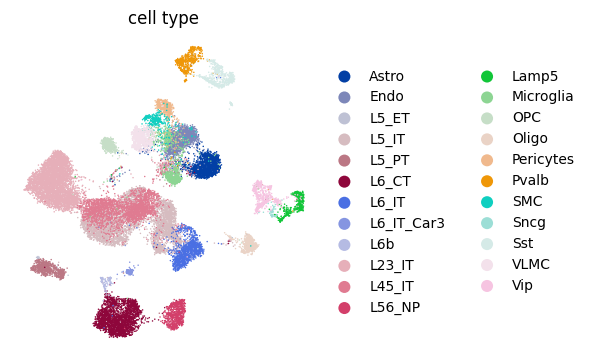

In [7]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.scatter(adata, basis='umap', color=['cell_type'], frameon=False)

### Calculating KNN indices for both COVET and ENVI

In [13]:
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

def compute_knn_indices(data, n_neighbors):
    n_samples = data.shape[0]
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(data)
    knn_indices = np.zeros((n_samples, n_neighbors), dtype=int)

    for i in tqdm(range(n_samples), desc="Computing kNN", ncols=80):
        _, indices = nbrs.kneighbors(data[i].reshape(1, -1))
        knn_indices[i] = indices[0]
        
    return knn_indices, nbrs

In [14]:
knn_indices_covet, _ = compute_knn_indices(covet_pca, n_neighbors=10)


Computing kNN: 100%|█████████████████████| 25932/25932 [00:47<00:00, 550.22it/s]


In [15]:
knn_indices_envi, _= compute_knn_indices(envi_pca, n_neighbors=10)

Computing kNN: 100%|█████████████████████| 25932/25932 [00:56<00:00, 461.59it/s]


In [16]:
print(knn_indices_envi.shape, knn_indices_covet.shape)


(25932, 10) (25932, 10)


### Computing snn matrix for both covet and envi

In [17]:
import numpy as np
from scipy.sparse import csr_matrix
from tqdm import tqdm

def compute_snn_matrix(knn_indices, n_neighbors=10):
    """
    Computes the Shared Nearest Neighbor (SNN) matrix using ranking-based weighting.

    :param knn_indices: (array) Indices of k-nearest neighbors for each point (n_samples, k)
    :param n_neighbors: (int) Number of nearest neighbors considered (default 10)
    :return: (sparse matrix) Weighted SNN graph in CSR format
    """
    n_samples = knn_indices.shape[0]
    snn_matrix = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Precompute neighbor sets and ranking dictionaries
    neighbor_sets = [set(knn_indices[i]) for i in range(n_samples)]
    rankings = [{knn_indices[i][j]: j + 1 for j in range(len(knn_indices[i]))} for i in range(n_samples)]

    for i in tqdm(range(n_samples), desc="Computing SNN Matrix", ncols=80):
        neighbors_i = neighbor_sets[i]

        for j in range(i + 1, n_samples):
            neighbors_j = neighbor_sets[j]
            shared_neighbors = neighbors_i.intersection(neighbors_j)

            if shared_neighbors:
                max_weight = max(
                    n_neighbors - 0.5 * (rankings[i][v] + rankings[j][v])
                    for v in shared_neighbors
                )
                # max_weight = max(0.5 * (rankings[i][v] + rankings[j][v])
                #     for v in shared_neighbors
                # )
                snn_matrix[i, j] = max_weight
                snn_matrix[j, i] = max_weight  # Symmetric assignment

    return csr_matrix(snn_matrix)


In [18]:
snn_envi=compute_snn_matrix(knn_indices_envi)

Computing SNN Matrix: 100%|██████████████| 25932/25932 [01:50<00:00, 233.89it/s]


In [20]:
snn_covet=compute_snn_matrix(knn_indices_covet)

Computing SNN Matrix: 100%|██████████████| 25932/25932 [01:50<00:00, 234.74it/s]


In [22]:
snn_combined = (snn_envi + snn_covet) / 2
print(snn_combined)

  (0, 18)	2.25
  (0, 60)	2.0
  (0, 73)	3.25
  (0, 142)	0.5
  (0, 194)	1.5
  (0, 206)	1.5
  (0, 241)	2.5
  (0, 400)	1.75
  (0, 436)	2.5
  (0, 511)	3.5
  (0, 521)	3.75
  (0, 557)	2.75
  (0, 583)	1.25
  (0, 585)	2.75
  (0, 597)	3.25
  (0, 631)	0.5
  (0, 671)	2.75
  (0, 753)	1.75
  (0, 805)	3.75
  (0, 854)	2.0
  (0, 1084)	1.75
  (0, 1097)	3.25
  (0, 1139)	1.25
  (0, 1149)	2.5
  (0, 1182)	2.25
  :	:
  (25931, 24312)	2.0
  (25931, 24445)	3.5
  (25931, 24542)	2.25
  (25931, 24591)	2.0
  (25931, 24753)	2.5
  (25931, 24786)	2.0
  (25931, 24837)	2.25
  (25931, 24897)	3.0
  (25931, 24965)	2.5
  (25931, 25038)	1.75
  (25931, 25062)	2.75
  (25931, 25118)	3.25
  (25931, 25242)	1.75
  (25931, 25272)	0.5
  (25931, 25312)	1.5
  (25931, 25376)	2.75
  (25931, 25405)	4.0
  (25931, 25442)	3.75
  (25931, 25544)	3.5
  (25931, 25567)	2.75
  (25931, 25626)	1.5
  (25931, 25631)	2.5
  (25931, 25643)	1.0
  (25931, 25651)	2.5
  (25931, 25868)	2.5


## Normalizing snn values to lie between 0 and 1

In [11]:
from sklearn.preprocessing import minmax_scale
from scipy.sparse import coo_matrix

# For sparse matrices:
snn_coo = snn_combined.tocoo()
scaled_data = minmax_scale(snn_coo.data)  # scales to [0, 1]
normalized_snn = sparse.coo_matrix((scaled_data, (snn_coo.row, snn_coo.col)), shape=snn_coo.shape)
print(normalized_snn)


  (0, 18)	0.2424242424242424
  (0, 60)	0.21212121212121213
  (0, 73)	0.36363636363636365
  (0, 142)	0.030303030303030304
  (0, 194)	0.15151515151515152
  (0, 206)	0.15151515151515152
  (0, 241)	0.2727272727272727
  (0, 400)	0.18181818181818182
  (0, 436)	0.2727272727272727
  (0, 511)	0.3939393939393939
  (0, 521)	0.4242424242424243
  (0, 557)	0.3030303030303031
  (0, 583)	0.12121212121212122
  (0, 585)	0.3030303030303031
  (0, 597)	0.36363636363636365
  (0, 631)	0.030303030303030304
  (0, 671)	0.3030303030303031
  (0, 753)	0.18181818181818182
  (0, 805)	0.4242424242424243
  (0, 854)	0.21212121212121213
  (0, 1084)	0.18181818181818182
  (0, 1097)	0.36363636363636365
  (0, 1139)	0.12121212121212122
  (0, 1149)	0.2727272727272727
  (0, 1182)	0.2424242424242424
  :	:
  (25931, 24312)	0.21212121212121213
  (25931, 24445)	0.3939393939393939
  (25931, 24542)	0.2424242424242424
  (25931, 24591)	0.21212121212121213
  (25931, 24753)	0.2727272727272727
  (25931, 24786)	0.21212121212121213
  (2593

In [23]:
from scipy import sparse

save_path = "/Users/anushka/Documents/Undergraduate-Project/Approaches/snn_combined_matrix.npz"
sparse.save_npz(save_path, snn_combined)


### Loading the snn combined matrix

In [8]:
from scipy import sparse

snn_combined = sparse.load_npz("/Users/anushka/Documents/Undergraduate-Project/Approaches/snn_combined_matrix.npz")


### Adding the snn combined to obsp of the adata so as to use it in the package directly

In [12]:
adata.obsp["snn_graph"] = snn_combined  
adata.obsp["snn_graph_normalized"]= normalized_snn


In [13]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'snn_graph', 'snn_graph_normalized'

In [14]:
raw_ad=sc.AnnData(adata.X)
raw_ad.obs_names, raw_ad.var_names=adata.obs_names, adata.var_names
adata.raw=raw_ad


## Creating Similarity Matrix

### Computing SNN based RBF Kernel

In [17]:
# optimization
# for parallelizing stuff
def snn_rbf_row(i, snn_dense_row):
    return np.exp(-1 / (snn_dense_row + 1e-8))

from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
NUM_CORES = cpu_count()

def snn_rbf_kernel(adata,  graph_construction="union"):
        """
        Compute the Shared Nearest Neighbor (SNN) based RBF kernel.
        Instead of Euclidean distance, we use SNN similarity scores.
        
        :return: (sparse matrix) SNN-RBF kernel matrix
        """

        snn_matrix= adata.obsp["snn_graph"]
        
        
        # Ensure symmetry in SNN matrix (if not already)
        sym_snn_matrix = (snn_matrix + snn_matrix.T) / 2
        n, d=adata.obsm["X_pca"].shape
        # Convert to dense format (if needed for iteration)
        snn_dense = sym_snn_matrix.toarray()
        num_cores = cpu_count()
        # Compute kernel using SNN weights instead of Euclidean distances
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
                    similarity_matrix_rows = parallel(
                        delayed(snn_rbf_row)(i, snn_dense[i]) for i in tqdm(range(n))
                        )
        
        
        similarity_matrix = lil_matrix((n,n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]
        
        # Ensure diagonal elements are exactly 1
        similarity_matrix.setdiag(1.0)
        
        
        M = similarity_matrix.tocsr()
        return M


In [18]:
similarity_matrix= snn_rbf_kernel(adata, snn_combined)

  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

### Computing Similarity matrix using the original seacells rbf function 

In [67]:
import multiprocessing
num_cores = multiprocessing.cpu_count()
def rbf_for_row(G, data, median_distances, i):
    """Helper function for computing radial basis function kernel for each row of the data matrix.

    :param G: (array) KNN graph representing nearest neighbour connections between cells
    :param data: (array) data matrix between which euclidean distances are computed for RBF
    :param median_distances: (array) radius for RBF - the median distance between cell and k nearest-neighbours
    :param i: (int) data row index for which RBF is calculated
    :return: sparse matrix containing computed RBF for row
    """
    # convert row to binary numpy array
    row_as_array = G[i, :].toarray().ravel()

    # compute distances ||x - y||^2 in PC/original X space
    numerator = np.sum(np.square(data[i, :] - data), axis=1, keepdims=False)

    # compute radii - median distance is distance to kth nearest neighbor
    denominator = median_distances[i] * median_distances

    # exp
    full_row = np.exp(-numerator / denominator)

    # masked row - to contain only indices captured by G matrix
    masked_row = np.multiply(full_row, row_as_array)

    return lil_matrix(masked_row)

def kth_neighbor_distance(distances, k, i):
    """Returns distance to kth nearest neighbor.

    Distances: sparse CSR matrix
    k: kth nearest neighbor
    i: index of row
    .
    """
    # convert row to 1D array
    row_as_array = distances[i, :].toarray().ravel()

    # number of nonzero elements
    num_nonzero = np.sum(row_as_array > 0)

    # argsort
    kth_neighbor_idx = np.argsort(np.argsort(-row_as_array)) == num_nonzero - k
    return np.linalg.norm(row_as_array[kth_neighbor_idx])


def rbf(adata, k: int = 15, graph_construction="union"):
        """Initialize adaptive bandwith RBF kernel (as described in C-isomap).

        :param k: (int) number of nearest neighbors for RBF kernel
        :return: (sparse matrix) constructed RBF kernel
        """
        import scanpy as sc

        knn_graph_distances = adata.obsp["distances"]
        n, d=adata.obsm["X_pca"].shape
        # Binarize distances to get connectivity
        knn_graph = knn_graph_distances.copy()
        knn_graph[knn_graph != 0] = 1
        # Include self as neighbour
        knn_graph.setdiag(1)

        knn_graph = knn_graph
        
            # compute median distance for each point amongst k-nearest neighbors
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            median = k // 2
            median_distances = parallel(
                delayed(kth_neighbor_distance)(knn_graph_distances, median, i)
                for i in tqdm(range(n))
            )

        # convert to numpy array
        median_distances = np.array(median_distances)

       
        print(
            f"Parameter graph_construction = {graph_construction} being used to build KNN graph..."
        )
        if graph_construction == "union":
            sym_graph = (knn_graph + knn_graph.T > 0).astype(float)
        elif graph_construction in ["intersect", "intersection"]:
            knn_graph = (knn_graph > 0).astype(float)
            sym_graph = knn_graph.multiply(knn_graph.T)
        else:
            raise ValueError(
                f"Parameter graph_construction = {graph_construction} is not valid. \
             Please select `union` or `intersection`"
            )
        
        sym_graph= sym_graph
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
            similarity_matrix_rows = parallel(
                delayed(rbf_for_row)(
                    sym_graph, adata.obsm["X_pca"], median_distances, i
                )
                for i in tqdm(range(n))
            )

      
        similarity_matrix = lil_matrix((n, n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]

        
        M = (similarity_matrix).tocsr()
        return M


In [68]:
similarity_matrix_rbf=rbf(adata)

  0%|          | 0/25932 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

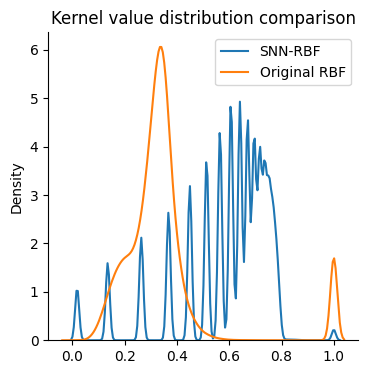

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(similarity_matrix.data, label="SNN-RBF")
sns.kdeplot(similarity_matrix_rbf.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()


### my custom rbf kernel seems too discretized as compared to the smooth gaussian kernel, which is something that seacells expects. how to fix that

## Smoother similarity matrix using the normalized data

In [19]:
# optimization
# for parallelizing stuff
def snn_rbf_row(i, snn_dense_row, sigma=0.3):
    data_array = np.asarray(snn_dense_row.data)  # Convert memoryview to array
    return np.exp(-((1.0 - data_array) ** 2) / (2 * sigma ** 2))

from multiprocessing import cpu_count
import numpy as np
from joblib import Parallel, delayed
from scipy.sparse import lil_matrix
from tqdm.notebook import tqdm
NUM_CORES = cpu_count()

def snn_rbf_kernel(snn, graph_construction="union"):
        """
        Compute the Shared Nearest Neighbor (SNN) based RBF kernel.
        Instead of Euclidean distance, we use SNN similarity scores.
        
        :return: (sparse matrix) SNN-RBF kernel matrix
        """

        snn_matrix= snn
        
        
        # Ensure symmetry in SNN matrix (if not already)
        sym_snn_matrix = (snn_matrix + snn_matrix.T) / 2
        n, d=adata.obsm["X_pca"].shape
        # Convert to dense format (if needed for iteration)
        snn_dense = sym_snn_matrix.toarray()
        num_cores = cpu_count()
        # Compute kernel using SNN weights instead of Euclidean distances
        with Parallel(n_jobs=num_cores, backend="threading") as parallel:
                    similarity_matrix_rows = parallel(
                        delayed(snn_rbf_row)(i, snn_dense[i]) for i in tqdm(range(n))
                        )
        
        
        similarity_matrix = lil_matrix((n,n))
        for i in tqdm(range(n)):
            similarity_matrix[i] = similarity_matrix_rows[i]
        
        # Ensure diagonal elements are exactly 1
        similarity_matrix.setdiag(1.0)
        
        
        M = similarity_matrix.tocsr()
        return M


In [20]:
similarity_matrix_post_normalization=snn_rbf_kernel(snn=normalized_snn)

  0%|          | 0/25932 [00:00<?, ?it/s]

  0%|          | 0/25932 [00:00<?, ?it/s]

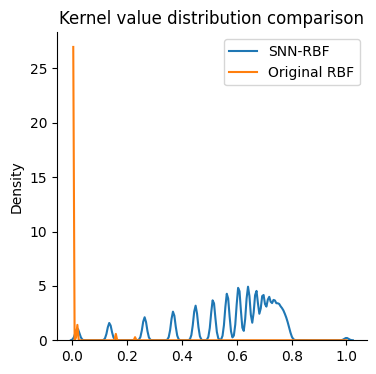

In [21]:
sns.kdeplot(similarity_matrix.data, label="SNN-RBF")
sns.kdeplot(similarity_matrix_post_normalization.data, label="Original RBF")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

In [23]:
from scipy import sparse

save_path = "/Users/anushka/Documents/Undergraduate-Project/Approaches/sim_matrix.npz"
sparse.save_npz(save_path, similarity_matrix_post_normalization)


In [19]:
similarity_matrix_post_normalization = sparse.load_npz("/Users/anushka/Documents/Undergraduate-Project/Approaches/sim_matrix.npz")


In [20]:
import SEACells

In [21]:
#Construct kernel matrix

n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [22]:
model= SEACells.core.SEACells(adata, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [24]:
model.construct_kernel_matrix_updated()

using your code
Using the updated rbf snn kernel code to calculate this matrix
welcome to snn rbf
Computing SNN-RBF Kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/25932 [00:00<?, ?it/s]

Constructing CSR matrix...


In [25]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 97 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 13/13 [00:07<00:00,  1.68it/s]

Selecting 3 cells from greedy initialization.


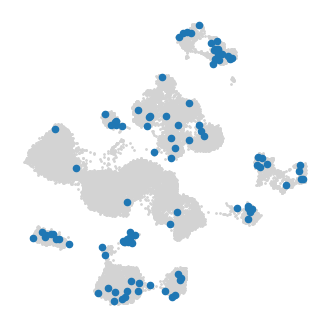

In [26]:
SEACells.plot.plot_initialization(adata, model)

In [27]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at 0.00195
Starting iteration 1.
Completed iteration 1.


KeyboardInterrupt: 

/Users/anushka/Documents/Undergraduate-Project/SEACells_updated/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


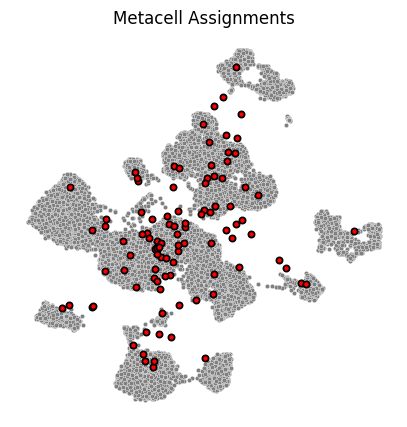

In [28]:
SEACells.plot.plot_2D(adata, colour_metacells=False)

/Users/anushka/Documents/Undergraduate-Project/SEACells_updated/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


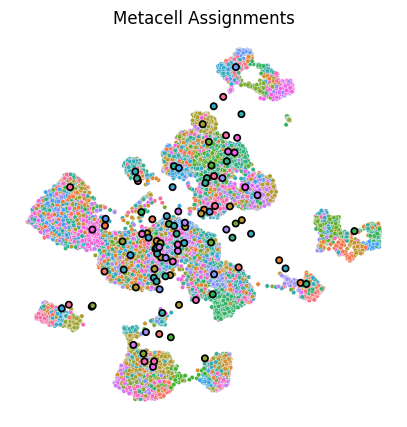

In [29]:
SEACells.plot.plot_2D(adata, colour_metacells=True)

In [ ]:
adata_envi=ad.AnnData(X=combined_envi_latent)
adata_envi.obs["cell_type"]=combined_cell_types
adata_envi.obsm["envi_latent"]= combined_envi_latent
print(adata_envi)

AnnData object with n_obs × n_vars = 25932 × 512
    obs: 'cell_type'
    obsm: 'envi_latent'


In [ ]:
adata_envi.obsp["connectivities"] = snn_envi  

In [ ]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type', 'jarvis_patrick_labels', 'dissolved', 'metacell', 'metacell_level'
    var: 'selected_gene'
    uns: 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
help(mc.pipeline.compute_divide_and_conquer_metacells)

Help on function compute_divide_and_conquer_metacells in module metacells.pipeline.divide_and_conquer:

compute_divide_and_conquer_metacells(adata: anndata._core.anndata.AnnData, what: str = '__x__', *, quick_and_dirty: bool = False, select_downsample_min_samples: int = 750, select_downsample_min_cell_quantile: float = 0.05, select_downsample_max_cell_quantile: float = 0.5, select_min_gene_total: Optional[int] = 50, select_min_gene_top3: Optional[int] = 4, select_min_gene_relative_variance: Optional[float] = 0.1, select_min_genes: int = 100, cells_similarity_value_regularization: float = 0.14285714285714285, cells_similarity_log_data: bool = True, cells_similarity_method: str = 'abs_pearson', groups_similarity_log_data: bool = True, groups_similarity_method: str = 'abs_pearson', target_metacell_umis: int = 160000, cell_umis: Optional[numpy.ndarray] = None, target_metacell_size: int = 48, min_metacell_size: int = 12, min_target_pile_size: int = 8000, max_target_pile_size: int = 24000, t

In [ ]:
import metacells as mc

mc.pipeline.divide_and_conquer.compute_divide_and_conquer_metacells(
    adata_envi,
    what="__x__",  
    target_metacell_size=48,
    min_metacell_size=12,
    target_metacell_umis=160000,
    min_target_pile_size=8000,
    max_target_pile_size=24000,
    target_metacells_in_pile=100,
    random_seed=42
)


set unnamed.var[selected_gene]: * -> False
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/metacells/tools/deviants.py:293: RuntimeWarning: invalid value encountered in log2
  log_fraction_per_gene_per_cell = np.log2(fraction_per_gene_per_cell + regularization_per_cell[:, np.newaxis])
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/metacells/tools/deviants.py:293: RuntimeWarning: invalid value encountered in log2
  log_fraction_per_gene_per_cell = np.log2(fraction_per_gene_per_cell + regularization_per_cell[:, np.newaxis])
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/metacells/tools/deviants.py:293: RuntimeWarning: invalid value encountered in log2
  log_fraction_per_gene_per_cell = np.log2(fraction_per_gene_per_cell + regularization_per_cell[:, np.newaxis])
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/metacells/pipeline/collect.py:201: RuntimeWarning: invalid value encountered in log2
  weight_per_cell_of_metacell = np.log2(umis_per_cell_of_metace

AssertionError: 

In [ ]:
print(adata.obs["metacell"].value_counts())  # See how many cells are in each metacell


metacell
0    25932
Name: count, dtype: int64


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 512 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


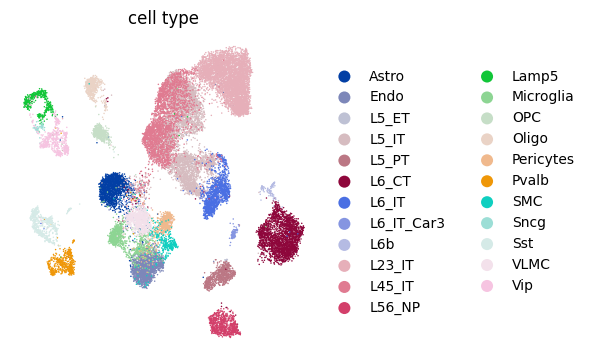

In [ ]:
sc.pp.neighbors(adata_envi, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_envi)
sc.pl.scatter(adata_envi, basis='umap', color=['cell_type'], frameon=False)

In [ ]:
umap_coords=adata_envi.obsm['X_umap']
print(umap_coords)

[[11.477362   8.475724 ]
 [ 9.878436  10.794941 ]
 [14.676215  -6.4497094]
 ...
 [ 9.220625   5.1821356]
 [ 3.0118809  3.6570053]
 [ 1.2073557 10.637166 ]]


In [ ]:
adata_envi.obs['jarvis_patrick_labels'] = pd.Categorical(labels)


In [ ]:
adata

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type', 'jarvis_patrick_labels'
    obsm: 'combined_matrix'

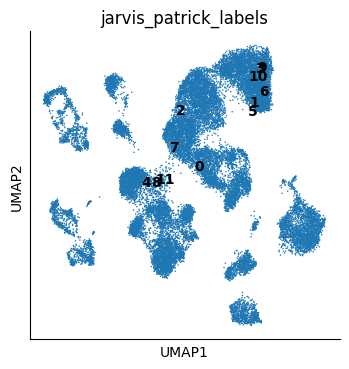

In [ ]:
sc.pl.umap(adata_envi, color='jarvis_patrick_labels', legend_loc='on data')

In [ ]:
print ("Shape of snn_envi: ", snn_envi.shape)


Shape of snn_envi:  (25932, 25932)


In [ ]:
snn_covet=compute_snn_matrix(knn_indices_covet)

Computing SNN Matrix: 100%|██████████████| 25932/25932 [02:18<00:00, 187.28it/s]


In [ ]:
print ("Shape of snn_covet: ",snn_covet.shape)

Shape of snn_covet:  (25932, 25932)


In [ ]:
snn=np.concatenate(snn_covet, snn_envi)

TypeError: 'csr_matrix' object cannot be interpreted as an integer

In [ ]:
from sklearn.cluster import DBSCAN

def cluster_with_dbscan(snn_matrix, eps=3, min_samples=5):
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = db.fit_predict(snn_matrix)
    return labels


In [ ]:
labels_envi=cluster_with_dbscan(snn_envi)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/sklearn/neighbors/_base.py:248: EfficiencyWarning: Precomputed sparse input was not sorted by row values. Use the function sklearn.neighbors.sort_graph_by_row_values to sort the input by row values, with warn_when_not_sorted=False to remove this warning.
  warnings.warn(


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_clusters(data, labels):
    tsne = TSNE(n_components=2, random_state=42)
    reduced_data = tsne.fit_transform(data)
    sns.scatterplot(x=reduced_data[:,0], y=reduced_data[:,1], hue=labels, palette='viridis')
    plt.title("DBSCAN Clusters using SNN")
    plt.show()


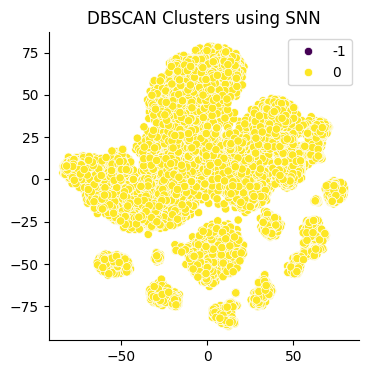

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
reduced_data = tsne.fit_transform(envi_pca)
sns.scatterplot(x=reduced_data[:,0], y=reduced_data[:,1], hue=labels_envi, palette='viridis')
plt.title("DBSCAN Clusters using SNN")
plt.show()